In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

In [2]:
data_path = Path("../Day46/data/sms_spam_eda.csv")

df = pd.read_csv(data_path)

df.head()

,label,message,message_length,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13


In [3]:
print("Dataset shape:", df.shape)
print(df["label"].value_counts())

Dataset shape: (5169, 4)
label
ham     4516
spam     653
Name: count, dtype: int64


In [4]:
X = df["message"]

y = df["label"]

In [5]:
y = y.map({
    "ham": 0,
    "spam": 1
})

y.value_counts()

label
0    4516
1     653
Name: count, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4135
Testing samples: 1034


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [10]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    max_features=5000
)

In [11]:
X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

In [12]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4135, 5000)
Testing TF-IDF shape: (1034, 5000)


In [13]:
from sklearn.linear_model import LogisticRegression

In [14]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [15]:
model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [16]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 0]


In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [18]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, zero_division=0)

recall = recall_score(y_test, y_pred, zero_division=0)

f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Accuracy:  0.9565
Precision: 0.9778
Recall:    0.6718
F1 Score:  0.7964


In [19]:
from sklearn.metrics import confusion_matrix

In [20]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[901   2]
 [ 43  88]]


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

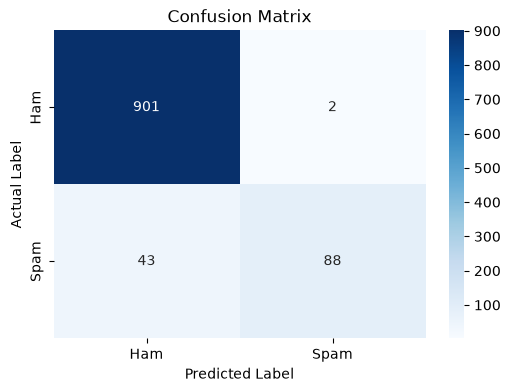

In [23]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [24]:
from sklearn.model_selection import GridSearchCV

In [25]:
param_grid = {
    "C": [0.1, 1, 10, 100]
}

In [26]:
tuning_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [27]:
grid_search = GridSearchCV(
    estimator=tuning_model,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

In [28]:
grid_search.fit(X_train_tfidf, y_train)

,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.1, 1, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [29]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'C': 100}


In [30]:
print("Best Cross-Validation F1 Score:", grid_search.best_score_)

Best Cross-Validation F1 Score: 0.9142976163864558


In [31]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test_tfidf)

In [32]:
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

precision_tuned = precision_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)

recall_tuned = recall_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)

f1_tuned = f1_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)

print(f"Tuned Accuracy:  {accuracy_tuned:.4f}")
print(f"Tuned Precision: {precision_tuned:.4f}")
print(f"Tuned Recall:    {recall_tuned:.4f}")
print(f"Tuned F1 Score:  {f1_tuned:.4f}")

Tuned Accuracy:  0.9787
Tuned Precision: 0.9739
Tuned Recall:    0.8550
Tuned F1 Score:  0.9106


In [33]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Baseline": [
        accuracy,
        precision,
        recall,
        f1
    ],
    "Tuned": [
        accuracy_tuned,
        precision_tuned,
        recall_tuned,
        f1_tuned
    ]
})

comparison

,Metric,Baseline,Tuned
0,Accuracy,0.956480,0.978723
1,Precision,0.977778,0.973913
2,Recall,0.671756,0.854962
3,F1 Score,0.796380,0.910569


In [34]:
experiment_log = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Tuned Logistic Regression"
    ],
    "Best C": [
        "Default",
        grid_search.best_params_["C"]
    ],
    "Accuracy": [
        accuracy,
        accuracy_tuned
    ],
    "Precision": [
        precision,
        precision_tuned
    ],
    "Recall": [
        recall,
        recall_tuned
    ],
    "F1 Score": [
        f1,
        f1_tuned
    ]
})

experiment_log

,Model,Best C,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,Default,0.956480,0.977778,0.671756,0.796380
1,Tuned Logistic Regression,100,0.978723,0.973913,0.854962,0.910569


In [35]:
from pathlib import Path

model_dir = Path("models")
model_dir.mkdir(exist_ok=True)

print("Model directory is ready!")

Model directory is ready!


In [36]:
%pip install joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
import joblib

In [38]:
model_path = model_dir / "spam_classifier.joblib"

joblib.dump(best_model, model_path)

print(f"Model saved to: {model_path}")

Model saved to: models\spam_classifier.joblib


In [39]:
vectorizer_path = model_dir / "tfidf_vectorizer.joblib"

joblib.dump(vectorizer, vectorizer_path)

print(f"Vectorizer saved to: {vectorizer_path}")

Vectorizer saved to: models\tfidf_vectorizer.joblib


In [40]:
log_path = Path("experiment_log.csv")

experiment_log.to_csv(log_path, index=False)

print(f"Experiment log saved to: {log_path}")

Experiment log saved to: experiment_log.csv


In [41]:
print("Saved files:")

for file in model_dir.iterdir():
    print(file)

print(log_path)

Saved files:
models\spam_classifier.joblib
models\tfidf_vectorizer.joblib
experiment_log.csv


In [42]:
loaded_model = joblib.load(model_path)

loaded_vectorizer = joblib.load(vectorizer_path)

print("Model and vectorizer loaded successfully!")

Model and vectorizer loaded successfully!


In [43]:
new_message = [
    "Congratulations! You have won a free prize. Claim now!"
]

new_message_tfidf = loaded_vectorizer.transform(new_message)

prediction = loaded_model.predict(new_message_tfidf)[0]

if prediction == 1:
    print("Prediction: Spam")
else:
    print("Prediction: Ham")

Prediction: Spam
